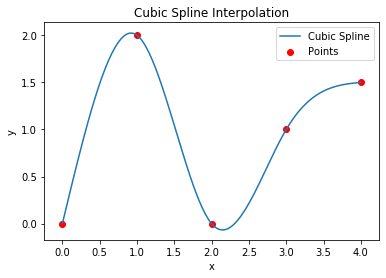

In [6]:
import numpy as np
import matplotlib.pyplot as plt


x = np.array([0, 1, 2, 3, 4], dtype=float)
y = np.array([0, 2, 0, 1, 1.5], dtype=float)

n = len(x)

h = np.diff(x)

A = np.zeros(n)
B = np.zeros(n)
C = np.zeros(n)
D = np.zeros(n)

B[0] = 1
B[-1] = 1
D[0] = 0
D[-1] = 0

for i in range(1, n - 1):
    A[i] = h[i - 1]
    B[i] = 2 * (h[i - 1] + h[i])
    C[i] = h[i]
    D[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

for i in range(1, n):
    w = A[i] / B[i - 1]
    B[i] = B[i] - w * C[i - 1]
    D[i] = D[i] - w * D[i - 1]

M = np.zeros(n)
M[-1] = D[-1] / B[-1]

for i in range(n - 2, -1, -1):
    M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

def evaluate_spline(x_eval, x, y, M):
    for i in range(len(x) - 1):
        if x[i] <= x_eval <= x[i + 1]:
            h = x[i + 1] - x[i]
            a = (x[i + 1] - x_eval) / h
            b = (x_eval - x[i]) / h
            
            term1 = (a**3 - a) * M[i] * (h**2) / 6
            term2 = (b**3 - b) * M[i + 1] * (h**2) / 6
            term3 = a * y[i]
            term4 = b * y[i + 1]
            
            return term1 + term2 + term3 + term4

    return None

#smooth curve
x_smooth = np.linspace(x[0], x[-1], 200)
y_smooth = np.array([evaluate_spline(xi, x, y, M) for xi in x_smooth])

#plot
plt.figure()
plt.plot(x_smooth, y_smooth, label="Cubic Spline")
plt.scatter(x, y, color='red', label="Points")
plt.legend()
plt.title("Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.show()